# 4.x Presentation Figures from Final Sequence Model Results

This notebook turns `output/fig/all-chro-modles.csv` into presentation-ready visuals and summary tables.
It focuses on three questions:

1. Which model wins each split-feature matchup?
2. Which choices are the most robust across splits?
3. What is the tradeoff between predictive accuracy and training cost?


In [1]:
import sys
from pathlib import Path

import matplotlib

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from IPython.display import display


def find_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'output').exists():
            return candidate
    raise RuntimeError('Project root not found from current working directory.')


ROOT = find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import FIG_OUTPUT

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 200,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'font.size': 10,
})


In [2]:
RESULTS_PATH = FIG_OUTPUT / 'all-chro-modles.csv'

df = pd.read_csv(RESULTS_PATH)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()

df['TrainingSeconds'] = df['Training_time'].str.rstrip('s').astype(float)
df['GainPct'] = df['Gain_vs_Analytic'].str.rstrip('%').astype(float)

df['feature_label'] = df['feature']
df['feature_short'] = df['feature']

MODEL_ORDER = ['FC', 'LSTM', 'GRU', 'TFT']
FEATURE_ORDER = ['6F', '8F rho', '8F theta']
SPLIT_ORDER = ['A', 'B', 'C', 'D']

MODEL_COLORS = {
    'FC': '#8c8c8c',
    'LSTM': '#4c78a8',
    'GRU': '#e45756',
    'TFT': '#54a24b',
}
FEATURE_MARKERS = {
    '6F': 'o',
    '8F rho': 's',
    '8F theta': '^',
}

for col, order in [('model', MODEL_ORDER), ('feature', FEATURE_ORDER), ('split', SPLIT_ORDER)]:
    df[col] = pd.Categorical(df[col], categories=order, ordered=True)

df = df.sort_values(['split', 'feature', 'model']).reset_index(drop=True)
print(df.shape)
display(df.head(8))


(48, 16)


,model,feature,split,SSE,MSE,RMSE,MAE,MeanError,MedianAE,R2,Training_time,Gain_vs_Analytic,TrainingSeconds,GainPct,feature_label,feature_short
0,FC,6F,A,77.695351,0.000134,0.011577,0.007890,-0.001475,0.005605,-1.696714,20.9s,-239.41%,20.9,-239.41,6F,6F
1,LSTM,6F,A,5.331666,0.000013,0.003538,0.001925,-0.000955,0.001227,0.690591,482.6s,62.11%,482.6,62.11,6F,6F
2,GRU,6F,A,4.134412,0.000010,0.003115,0.001504,-0.000219,0.000814,0.760070,682.4s,70.62%,682.4,70.62,6F,6F
3,TFT,6F,A,27.004593,0.000063,0.007961,0.006076,-0.005758,0.004694,-0.567142,1050.0s,-91.90%,1050.0,-91.90,6F,6F
4,FC,8F rho,A,90.568047,0.000156,0.012499,0.007895,0.000739,0.004868,-2.143510,25.4s,-295.64%,25.4,-295.64,8F rho,8F rho
5,LSTM,8F rho,A,5.672985,0.000013,0.003649,0.001961,-0.001101,0.001002,0.670783,689.7s,59.69%,689.7,59.69,8F rho,8F rho
6,GRU,8F rho,A,3.748081,0.000009,0.002966,0.001415,-0.000505,0.000767,0.782490,1007.0s,73.36%,1007.0,73.36,8F rho,8F rho
7,TFT,8F rho,A,12.468952,0.000029,0.005410,0.003809,-0.003305,0.002761,0.276397,1587.9s,11.39%,1587.9,11.39,8F rho,8F rho


## Summary Tables

The two tables below are the quickest slide appendix material:

- `model_feature_summary`: average performance and stability for each model-feature pair.
- `winner_table`: best model in each split-feature bucket, with the runner-up gap.


In [3]:
model_feature_summary = (
    df.groupby(['model', 'feature_label'], observed=True)
      .agg(
          avg_r2=('R2', 'mean'),
          std_r2=('R2', 'std'),
          worst_r2=('R2', 'min'),
          avg_rmse=('RMSE', 'mean'),
          avg_mae=('MAE', 'mean'),
          avg_gain_pct=('GainPct', 'mean'),
          avg_training_s=('TrainingSeconds', 'mean'),
      )
      .reset_index()
)

model_feature_summary['rank_r2'] = model_feature_summary['avg_r2'].rank(ascending=False, method='dense')
model_feature_summary['rank_rmse'] = model_feature_summary['avg_rmse'].rank(ascending=True, method='dense')
model_feature_summary['rank_gain'] = model_feature_summary['avg_gain_pct'].rank(ascending=False, method='dense')
model_feature_summary['rank_time'] = model_feature_summary['avg_training_s'].rank(ascending=True, method='dense')
model_feature_summary['overall_score'] = (
    model_feature_summary[['rank_r2', 'rank_rmse', 'rank_gain', 'rank_time']].mean(axis=1)
)

model_feature_summary = model_feature_summary.sort_values(
    ['overall_score', 'avg_r2', 'avg_gain_pct'], ascending=[True, False, False]
).reset_index(drop=True)

winner_rows = []
for split in SPLIT_ORDER:
    for feature in FEATURE_ORDER:
        block = df[(df['split'] == split) & (df['feature'] == feature)].sort_values('R2', ascending=False).reset_index(drop=True)
        best = block.iloc[0]
        runner_up = block.iloc[1]
        winner_rows.append({
            'split': split,
            'feature_label': best['feature_label'],
            'winner_model': best['model'],
            'winner_r2': best['R2'],
            'winner_rmse': best['RMSE'],
            'winner_gain_pct': best['GainPct'],
            'winner_training_s': best['TrainingSeconds'],
            'runner_up_model': runner_up['model'],
            'runner_up_r2': runner_up['R2'],
            'r2_gap_vs_runner_up': best['R2'] - runner_up['R2'],
        })

winner_table = pd.DataFrame(winner_rows).sort_values(['split', 'feature_label']).reset_index(drop=True)

# model_feature_summary.to_csv(FIG_OUTPUT / '4.x-model-feature-summary.csv', index=False)
# winner_table.to_csv(FIG_OUTPUT / '4.x-split-feature-winners.csv', index=False)

summary_display = model_feature_summary.copy()
summary_display[['avg_r2', 'std_r2', 'worst_r2', 'avg_rmse', 'avg_mae']] = summary_display[['avg_r2', 'std_r2', 'worst_r2', 'avg_rmse', 'avg_mae']].round(4)
summary_display[['avg_gain_pct', 'avg_training_s', 'overall_score']] = summary_display[['avg_gain_pct', 'avg_training_s', 'overall_score']].round(2)
display(summary_display)

winner_display = winner_table.copy()
winner_display[['winner_r2', 'winner_rmse', 'winner_gain_pct', 'winner_training_s', 'runner_up_r2', 'r2_gap_vs_runner_up']] = winner_display[['winner_r2', 'winner_rmse', 'winner_gain_pct', 'winner_training_s', 'runner_up_r2', 'r2_gap_vs_runner_up']].round(4)
display(winner_display)


,model,feature_label,avg_r2,std_r2,worst_r2,avg_rmse,avg_mae,avg_gain_pct,avg_training_s,rank_r2,rank_rmse,rank_gain,rank_time,overall_score
0,GRU,8F rho,0.7598,0.1774,0.5071,0.0035,0.0018,73.76,511.42,1.0,1.0,1.0,9.0,3.00
1,GRU,6F,0.6693,0.4079,0.0688,0.0037,0.0020,63.73,480.52,2.0,2.0,2.0,8.0,3.50
2,LSTM,8F rho,0.6681,0.2700,0.2915,0.0040,0.0022,63.54,307.80,3.0,3.0,3.0,6.0,3.75
3,LSTM,6F,0.6133,0.3284,0.1475,0.0043,0.0024,57.92,297.02,5.0,5.0,5.0,5.0,5.00
4,GRU,8F theta,0.5979,0.3540,0.1008,0.0042,0.0021,57.27,377.70,6.0,4.0,6.0,7.0,5.75
5,TFT,8F theta,0.6150,0.2050,0.4101,0.0045,0.0028,58.01,757.40,4.0,6.0,4.0,12.0,6.50
6,LSTM,8F theta,0.3899,0.6367,-0.5377,0.0050,0.0025,36.00,149.70,8.0,8.0,8.0,4.0,7.00
7,TFT,8F rho,0.5163,0.3491,0.1659,0.0048,0.0031,45.89,703.15,7.0,7.0,7.0,11.0,8.00
8,FC,8F theta,-0.6618,1.0870,-2.2876,0.0102,0.0064,-89.76,32.02,10.0,10.0,10.0,2.0,8.00
9,FC,8F rho,-0.8661,1.0968,-2.1435,0.0104,0.0064,-109.10,33.28,11.0,11.0,11.0,3.0,9.00


,split,feature_label,winner_model,winner_r2,winner_rmse,winner_gain_pct,winner_training_s,runner_up_model,runner_up_r2,r2_gap_vs_runner_up
0,A,6F,GRU,0.7601,0.0031,70.62,682.4,LSTM,0.6906,0.0695
1,A,8F rho,GRU,0.7825,0.0030,73.36,1007.0,LSTM,0.6708,0.1117
2,A,8F theta,GRU,0.6316,0.0039,54.88,411.9,LSTM,0.5752,0.0564
3,B,6F,GRU,0.9423,0.0030,94.06,435.0,LSTM,0.9197,0.0226
4,B,8F rho,GRU,0.9172,0.0036,91.48,404.1,LSTM,0.9141,0.0031
5,B,8F theta,GRU,0.9305,0.0033,92.85,412.3,LSTM,0.9122,0.0184
6,C,6F,GRU,0.9058,0.0019,90.64,741.0,LSTM,0.6955,0.2103
7,C,8F rho,GRU,0.8325,0.0025,83.35,532.7,LSTM,0.7960,0.0365
8,C,8F theta,TFT,0.4101,0.0047,41.35,558.7,GRU,0.1008,0.3093
9,D,6F,LSTM,0.1475,0.0066,8.09,54.6,TFT,0.0819,0.0656


## Figure 1. R2 Heatmap Grid

A compact 2x2 grid makes it easy to compare all model families within each split.
Green cells indicate stronger explanatory power, red cells indicate weak or negative out-of-sample fit.


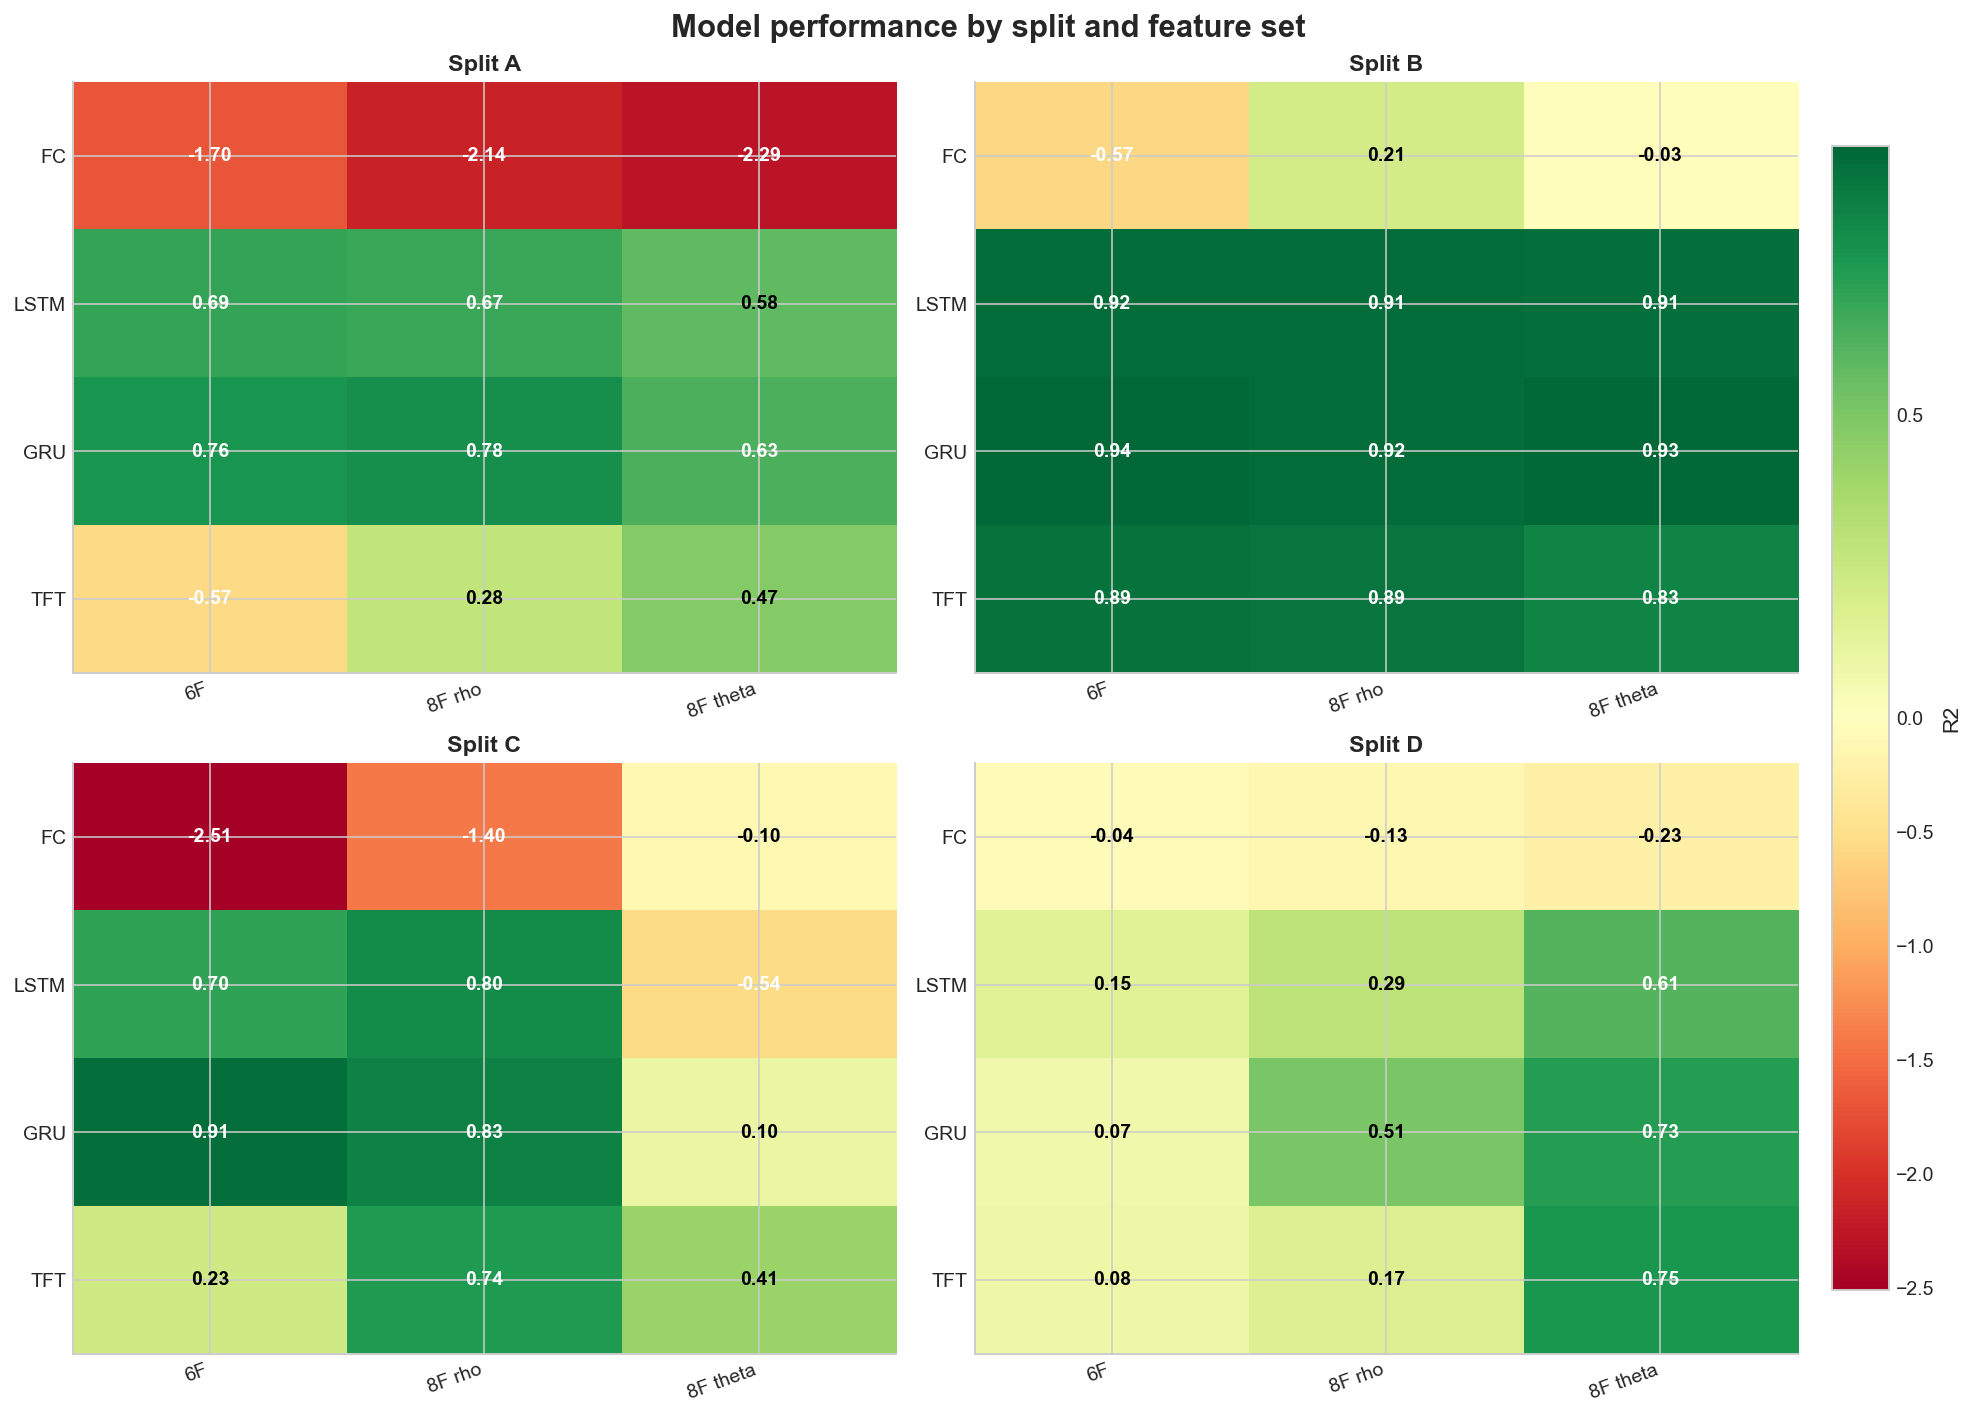

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
norm = colors.TwoSlopeNorm(vmin=df['R2'].min(), vcenter=0.0, vmax=df['R2'].max())
cmap = plt.cm.RdYlGn

for ax, split in zip(axes.flat, SPLIT_ORDER):
    heat = (
        df[df['split'] == split]
        .pivot(index='model', columns='feature_label', values='R2')
        .reindex(index=MODEL_ORDER)
    )
    im = ax.imshow(heat.values, cmap=cmap, norm=norm, aspect='auto')

    ax.set_title(f'Split {split}')
    ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=20, ha='right')
    ax.set_yticks(range(len(heat.index)), heat.index)

    for row_idx, model in enumerate(heat.index):
        for col_idx, feature in enumerate(heat.columns):
            value = heat.loc[model, feature]
            text_color = 'black' if -0.4 <= value <= 0.6 else 'white'
            ax.text(col_idx, row_idx, f'{value:.2f}', ha='center', va='center', fontsize=10, color=text_color, fontweight='bold')

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('R2')
fig.suptitle('Model performance by split and feature set', fontsize=16, fontweight='bold')
# fig.savefig(FIG_OUTPUT / '4.1-r2-heatmap-grid.png', bbox_inches='tight')
plt.show()


## Figure 2. Winner Map

This chart compresses the full model comparison into a 4x3 scorecard. Each tile shows the winning model for that split-feature bucket, its `R2`, and its `Gain vs Analytic`.


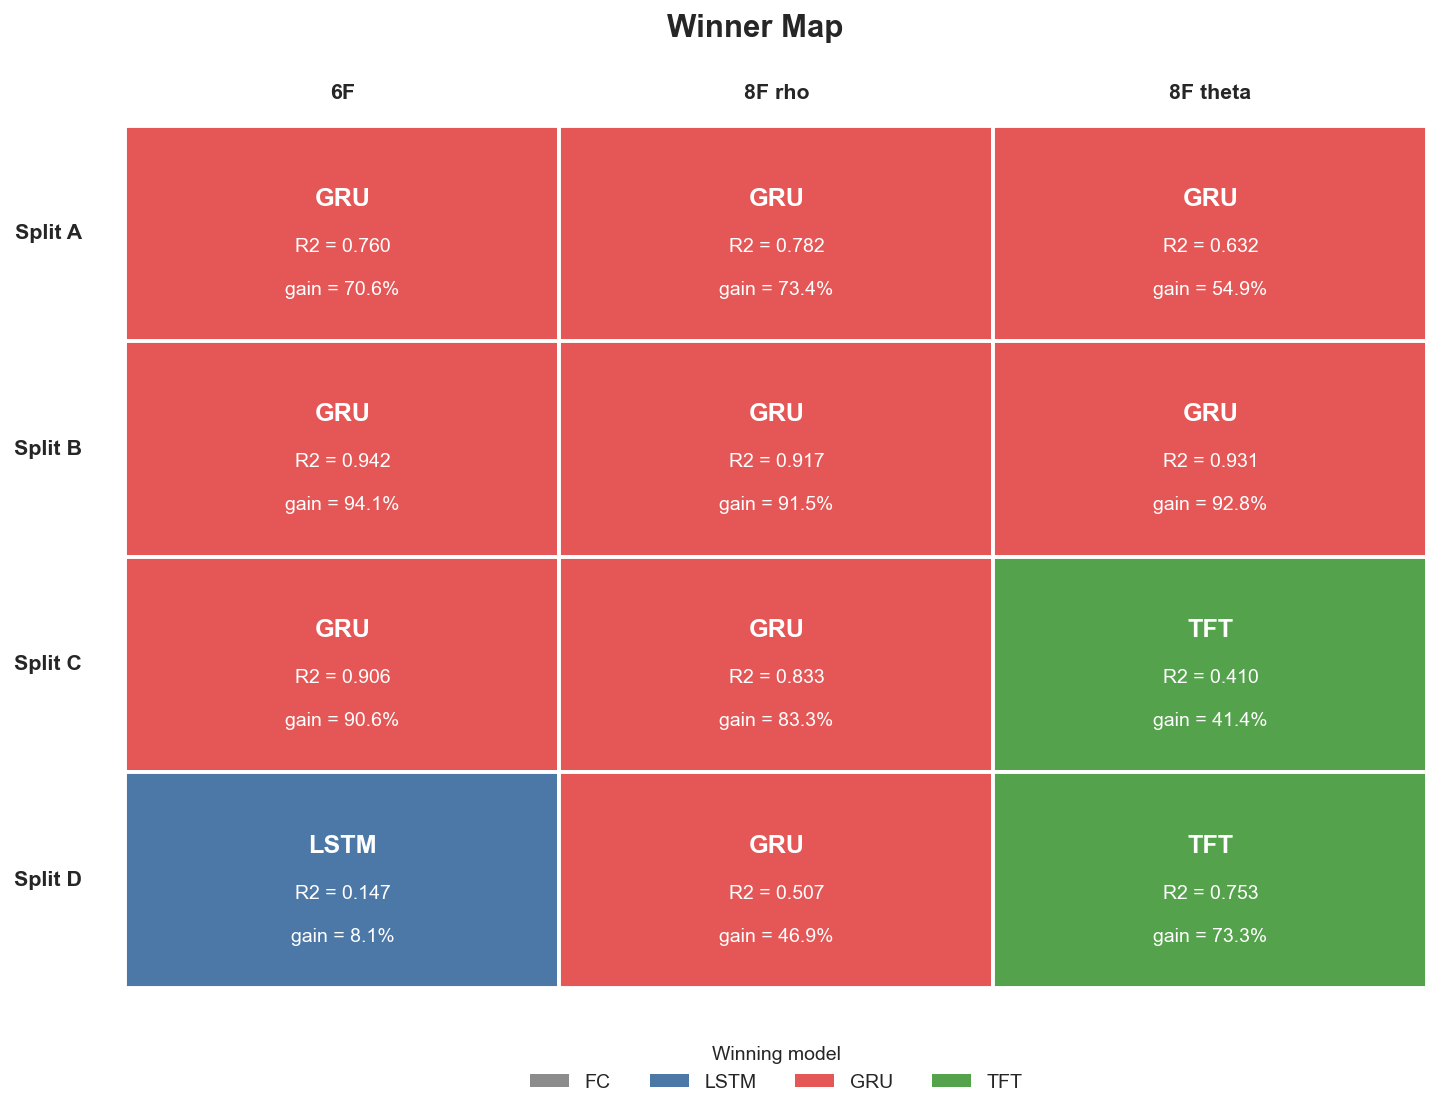

In [32]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, len(FEATURE_ORDER))
ax.set_ylim(0, len(SPLIT_ORDER))
ax.invert_yaxis()
ax.axis('off')

for x_idx, feature in enumerate(FEATURE_ORDER):
    ax.text(x_idx + 0.5, -0.15, df.loc[df['feature'] == feature, 'feature_label'].iloc[0],
            ha='center', va='center', fontsize=11, fontweight='bold')

for y_idx, split in enumerate(SPLIT_ORDER):
    ax.text(-0.1, y_idx + 0.5, f'Split {split}', ha='right', va='center', fontsize=11, fontweight='bold')
    for x_idx, feature in enumerate(FEATURE_ORDER):
        block = df[(df['split'] == split) & (df['feature'] == feature)].sort_values('R2', ascending=False).reset_index(drop=True)
        best = block.iloc[0]
        rect = Rectangle((x_idx, y_idx), 1, 1, facecolor=MODEL_COLORS[best['model']], edgecolor='white', linewidth=2)
        ax.add_patch(rect)
        ax.text(x_idx + 0.5, y_idx + 0.34, best['model'], ha='center', va='center', fontsize=13, color='white', fontweight='bold')
        ax.text(x_idx + 0.5, y_idx + 0.56, f"R2 = {best['R2']:.3f}", ha='center', va='center', fontsize=10, color='white')
        ax.text(x_idx + 0.5, y_idx + 0.76, f"gain = {best['GainPct']:.1f}%", ha='center', va='center', fontsize=10, color='white')

legend_handles = [Rectangle((0, 0), 1, 1, facecolor=MODEL_COLORS[m], label=m) for m in MODEL_ORDER]
ax.legend(handles=legend_handles, title='Winning model', ncols=4, loc='lower center', bbox_to_anchor=(0.5, -0.14), frameon=False)
fig.suptitle('Winner Map', fontsize=16, fontweight='bold')
fig.savefig(FIG_OUTPUT / '4.2-winner-map.png', bbox_inches='tight')
plt.show()


## Figure 3. Rank Trajectories Across Splits

Each subplot keeps one feature set fixed and tracks the rank order of model families from split A to D.
This is useful when you want to talk about robustness rather than one-off wins.


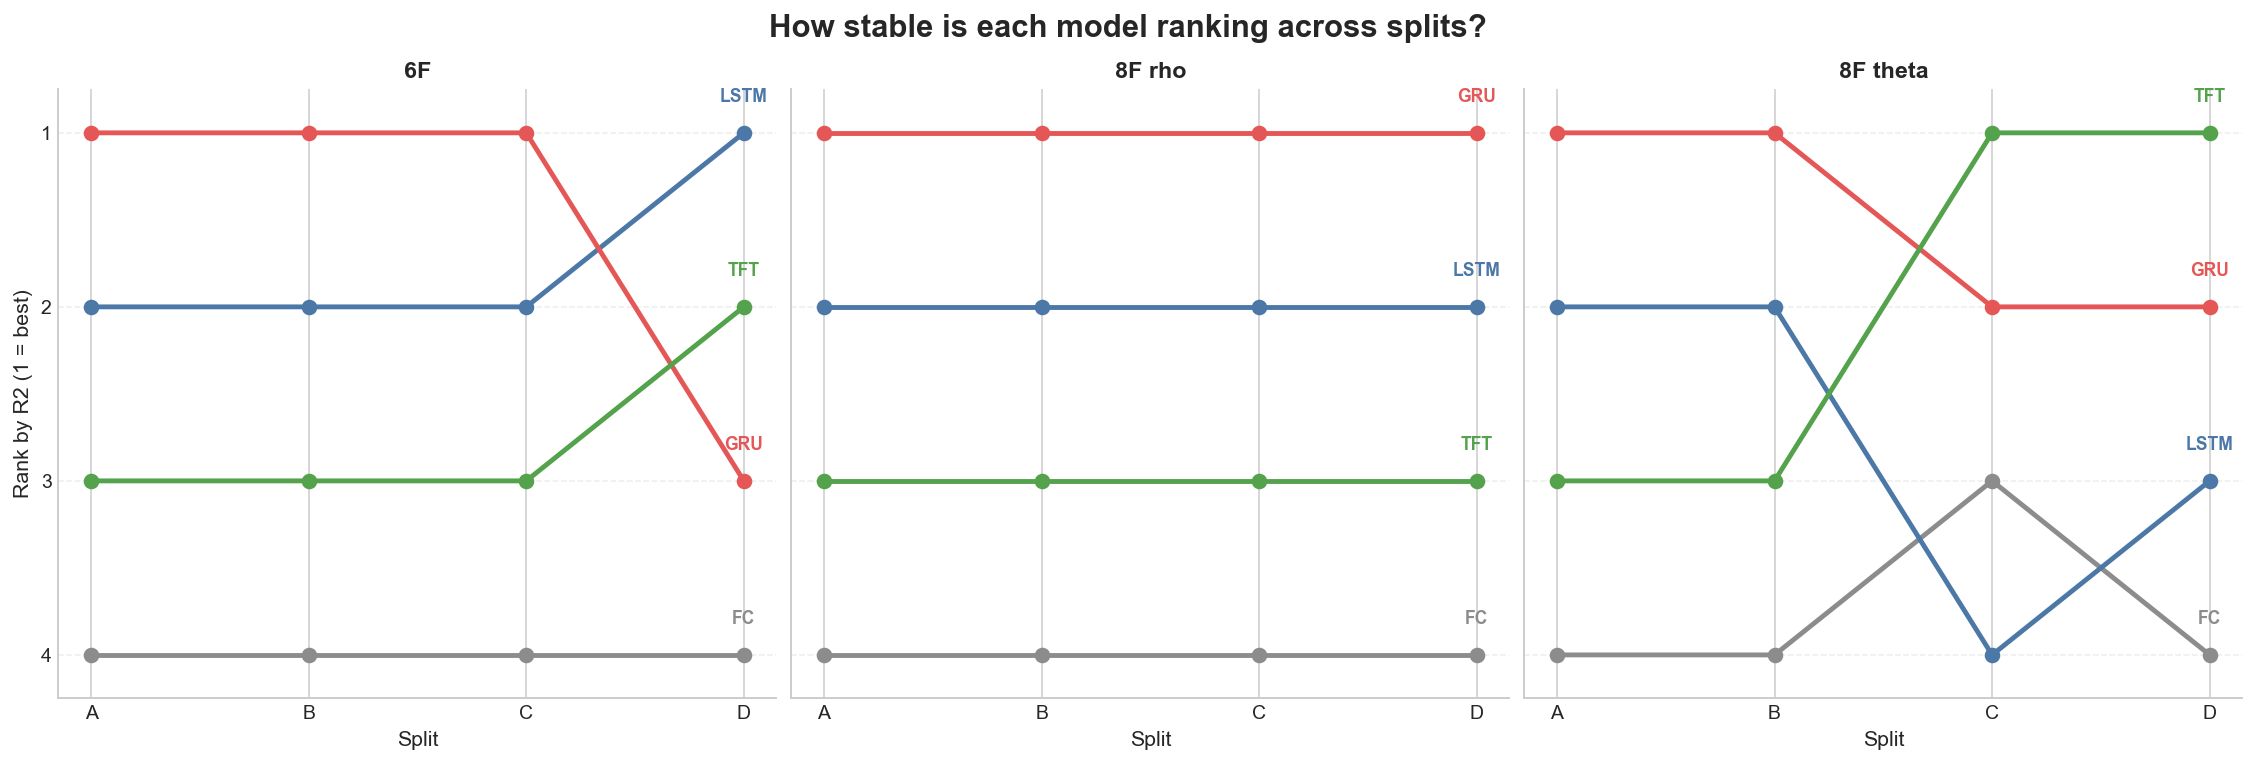

In [6]:
rank_df = df.copy()
rank_df['rank'] = rank_df.groupby(['split', 'feature'], observed=True)['R2'].rank(ascending=False, method='first')

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, constrained_layout=True)

for ax, feature in zip(axes, FEATURE_ORDER):
    feature_slice = rank_df[rank_df['feature'] == feature].copy()
    for model in MODEL_ORDER:
        line = feature_slice[feature_slice['model'] == model].sort_values('split')
        ax.plot(
            line['split'].astype(str),
            line['rank'],
            color=MODEL_COLORS[model],
            marker='o',
            linewidth=2.5,
            markersize=7,
            label=model,
        )
        final_row = line.sort_values('split').iloc[-1]
        ax.text(final_row['split'], final_row['rank'] - 0.18, model, color=MODEL_COLORS[model], fontsize=9, fontweight='bold', ha='center')

    label = feature_slice['feature_label'].iloc[0]
    ax.set_title(label)
    ax.set_xlabel('Split')
    ax.set_xticks(SPLIT_ORDER)
    ax.set_ylim(4.25, 0.75)
    ax.set_yticks([1, 2, 3, 4])
    ax.grid(axis='y', linestyle='--', alpha=0.35)

axes[0].set_ylabel('Rank by R2 (1 = best)')
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle('How stable is each model ranking across splits?', fontsize=16, fontweight='bold', y=1.06)
# fig.savefig(FIG_OUTPUT / '4.3-rank-trajectories.png', bbox_inches='tight')
plt.show()


## Figure 4. Accuracy vs Training Cost Frontier

This figure highlights the practical tradeoff: some models are only better if their extra training time is justified.
Points with a black outline lie on the split-specific Pareto frontier.


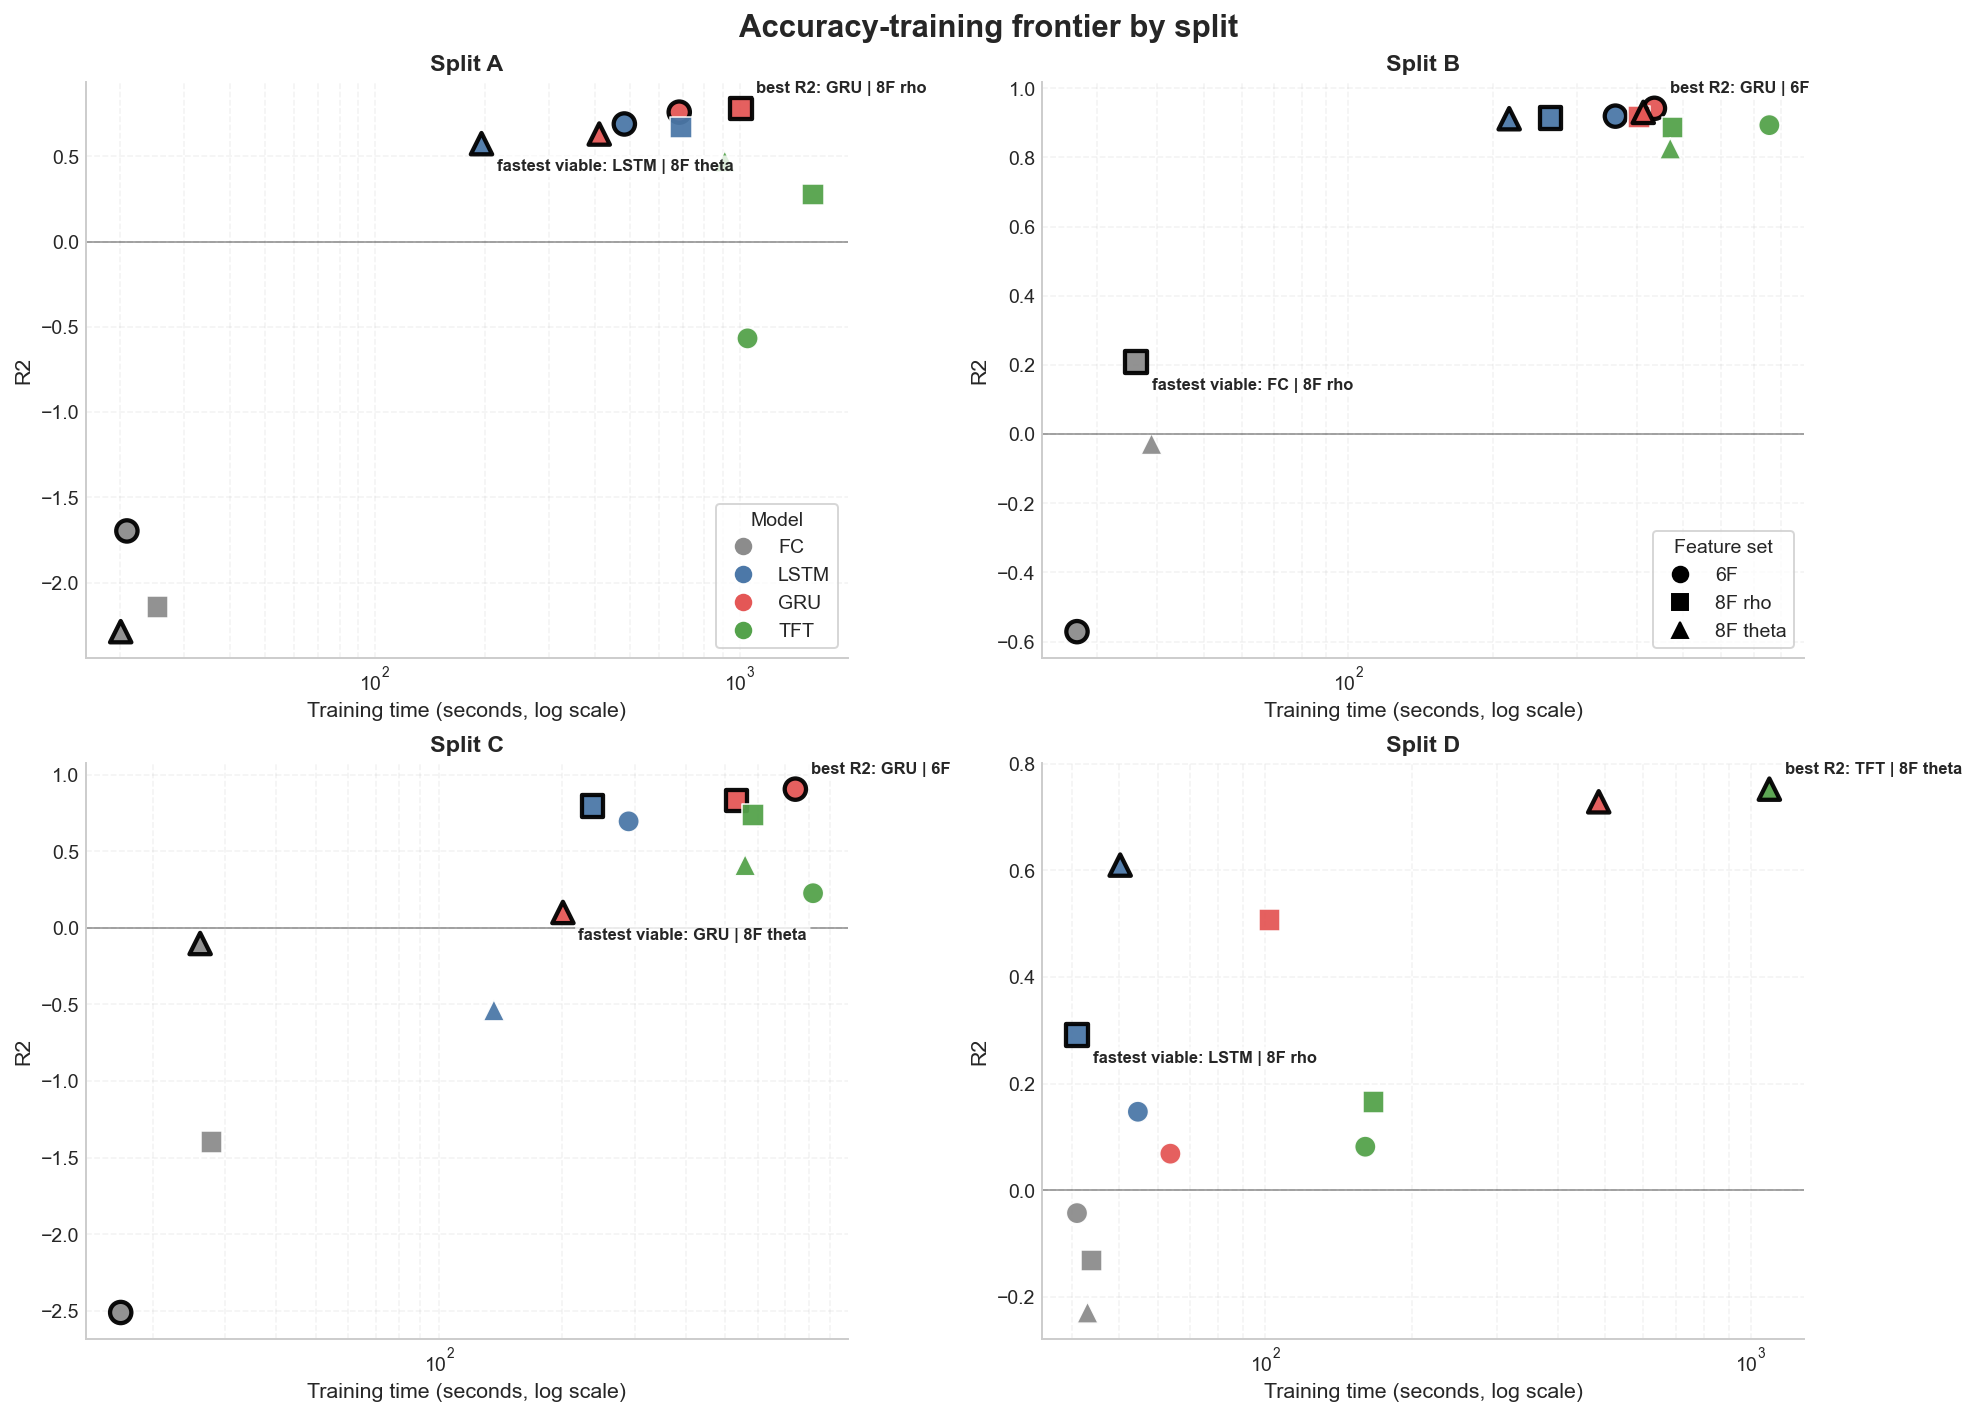

In [7]:
def pareto_frontier(frame: pd.DataFrame) -> pd.Series:
    mask = []
    for idx, row in frame.iterrows():
        dominated = frame[
            (frame['TrainingSeconds'] <= row['TrainingSeconds'])
            & (frame['R2'] >= row['R2'])
            & ((frame['TrainingSeconds'] < row['TrainingSeconds']) | (frame['R2'] > row['R2']))
        ]
        mask.append(dominated.empty)
    return pd.Series(mask, index=frame.index)


fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

for ax, split in zip(axes.flat, SPLIT_ORDER):
    block = df[df['split'] == split].copy()
    block['is_frontier'] = pareto_frontier(block)

    for feature in FEATURE_ORDER:
        sub = block[block['feature'] == feature]
        ax.scatter(
            sub['TrainingSeconds'],
            sub['R2'],
            s=120,
            c=sub['model'].map(MODEL_COLORS),
            marker=FEATURE_MARKERS[feature],
            edgecolor=np.where(sub['is_frontier'], 'black', 'white'),
            linewidth=np.where(sub['is_frontier'], 2.2, 0.8),
            alpha=0.95,
        )

    best_accuracy = block.loc[block['R2'].idxmax()]
    viable = block[block['R2'] >= 0].copy()
    fastest_viable = viable.loc[viable['TrainingSeconds'].idxmin()]

    spotlight = pd.DataFrame([best_accuracy, fastest_viable]).drop_duplicates(subset=['model', 'feature', 'split'])
    for _, row in spotlight.iterrows():
        label_kind = 'best R2' if row['R2'] == best_accuracy['R2'] else 'fastest viable'
        ax.annotate(
            f"{label_kind}: {row['model']} | {row['feature_short']}",
            (row['TrainingSeconds'], row['R2']),
            xytext=(8, 8 if label_kind == 'best R2' else -14),
            textcoords='offset points',
            fontsize=8.5,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
        )

    ax.set_title(f'Split {split}')
    ax.set_xscale('log')
    ax.set_xlabel('Training time (seconds, log scale)')
    ax.set_ylabel('R2')
    ax.axhline(0, color='black', linewidth=1, alpha=0.35)
    ax.grid(True, which='both', linestyle='--', alpha=0.25)

model_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=MODEL_COLORS[m], markeredgecolor='none', markersize=9, label=m)
    for m in MODEL_ORDER
]
feature_handles = [
    Line2D([0], [0], marker=FEATURE_MARKERS[f], color='black', linestyle='None', markersize=8, label=df.loc[df['feature'] == f, 'feature_short'].iloc[0])
    for f in FEATURE_ORDER
]
axes[0, 0].legend(handles=model_handles, title='Model', loc='lower right', frameon=True)
axes[0, 1].legend(handles=feature_handles, title='Feature set', loc='lower right', frameon=True)
fig.suptitle('Accuracy-training frontier by split', fontsize=16, fontweight='bold')
# fig.savefig(FIG_OUTPUT / '4.4-accuracy-vs-time-frontier.png', bbox_inches='tight')
plt.show()


## Figure 5. Robustness Scorecards

These panels aggregate over splits. Bars show mean `R2`, error bars show cross-split standard deviation, and labels add average gain and average training time.


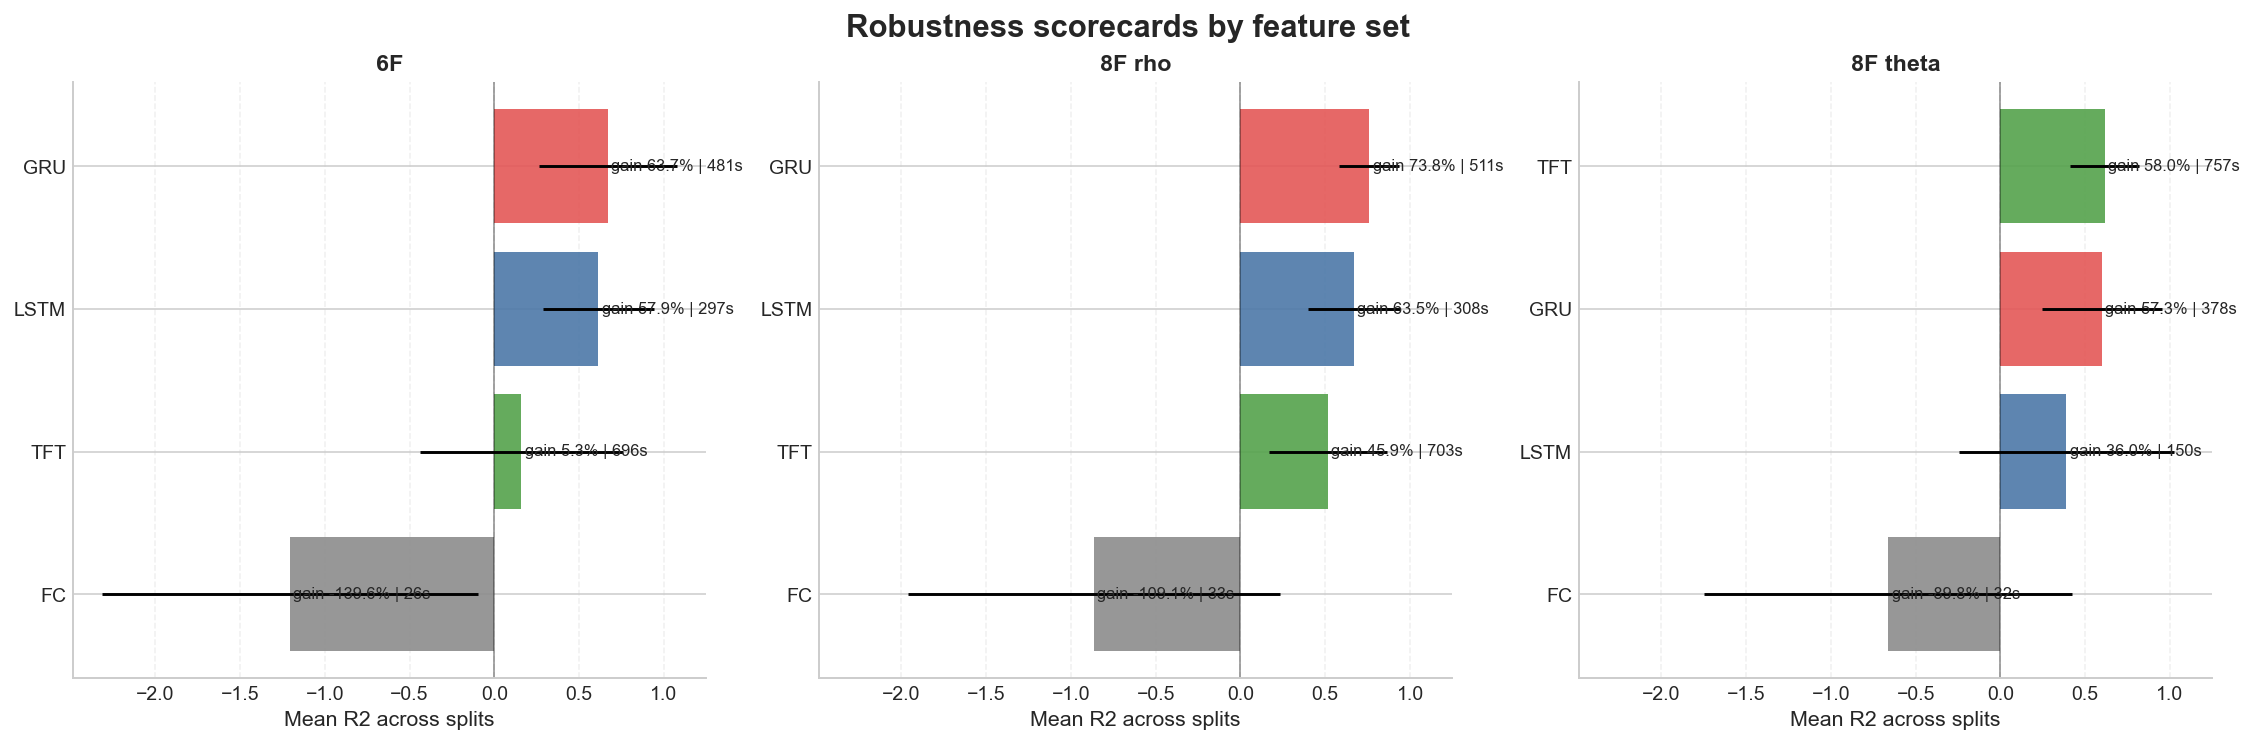

In [8]:
robustness = (
    df.groupby(['feature', 'feature_label', 'model'], observed=True)
      .agg(
          mean_r2=('R2', 'mean'),
          std_r2=('R2', 'std'),
          mean_gain=('GainPct', 'mean'),
          mean_time=('TrainingSeconds', 'mean'),
      )
      .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, constrained_layout=True)

for ax, feature in zip(axes, FEATURE_ORDER):
    sub = robustness[robustness['feature'] == feature].sort_values('mean_r2', ascending=True)
    y = np.arange(len(sub))
    ax.barh(y, sub['mean_r2'], xerr=sub['std_r2'].fillna(0), color=sub['model'].map(MODEL_COLORS), alpha=0.9)
    ax.set_yticks(y, sub['model'])
    ax.set_title(sub['feature_label'].iloc[0])
    ax.axvline(0, color='black', linewidth=1, alpha=0.35)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    for yi, row in enumerate(sub.itertuples()):
        ax.text(
            row.mean_r2 + 0.02,
            yi,
            f"gain {row.mean_gain:.1f}% | {row.mean_time:.0f}s",
            va='center',
            fontsize=8.5,
        )

axes[0].set_xlabel('Mean R2 across splits')
axes[1].set_xlabel('Mean R2 across splits')
axes[2].set_xlabel('Mean R2 across splits')
fig.suptitle('Robustness scorecards by feature set', fontsize=16, fontweight='bold')
# fig.savefig(FIG_OUTPUT / '4.5-robustness-scorecards.png', bbox_inches='tight')
plt.show()


## Figure 6. Gain Heatmap for Sequence Models

This view removes FC and compares only `LSTM`, `GRU`, and `TFT` on `Gain_vs_Analytic`.
It is the quickest chart for showing which sequence model delivers the strongest benchmark lift in each split-feature bucket.


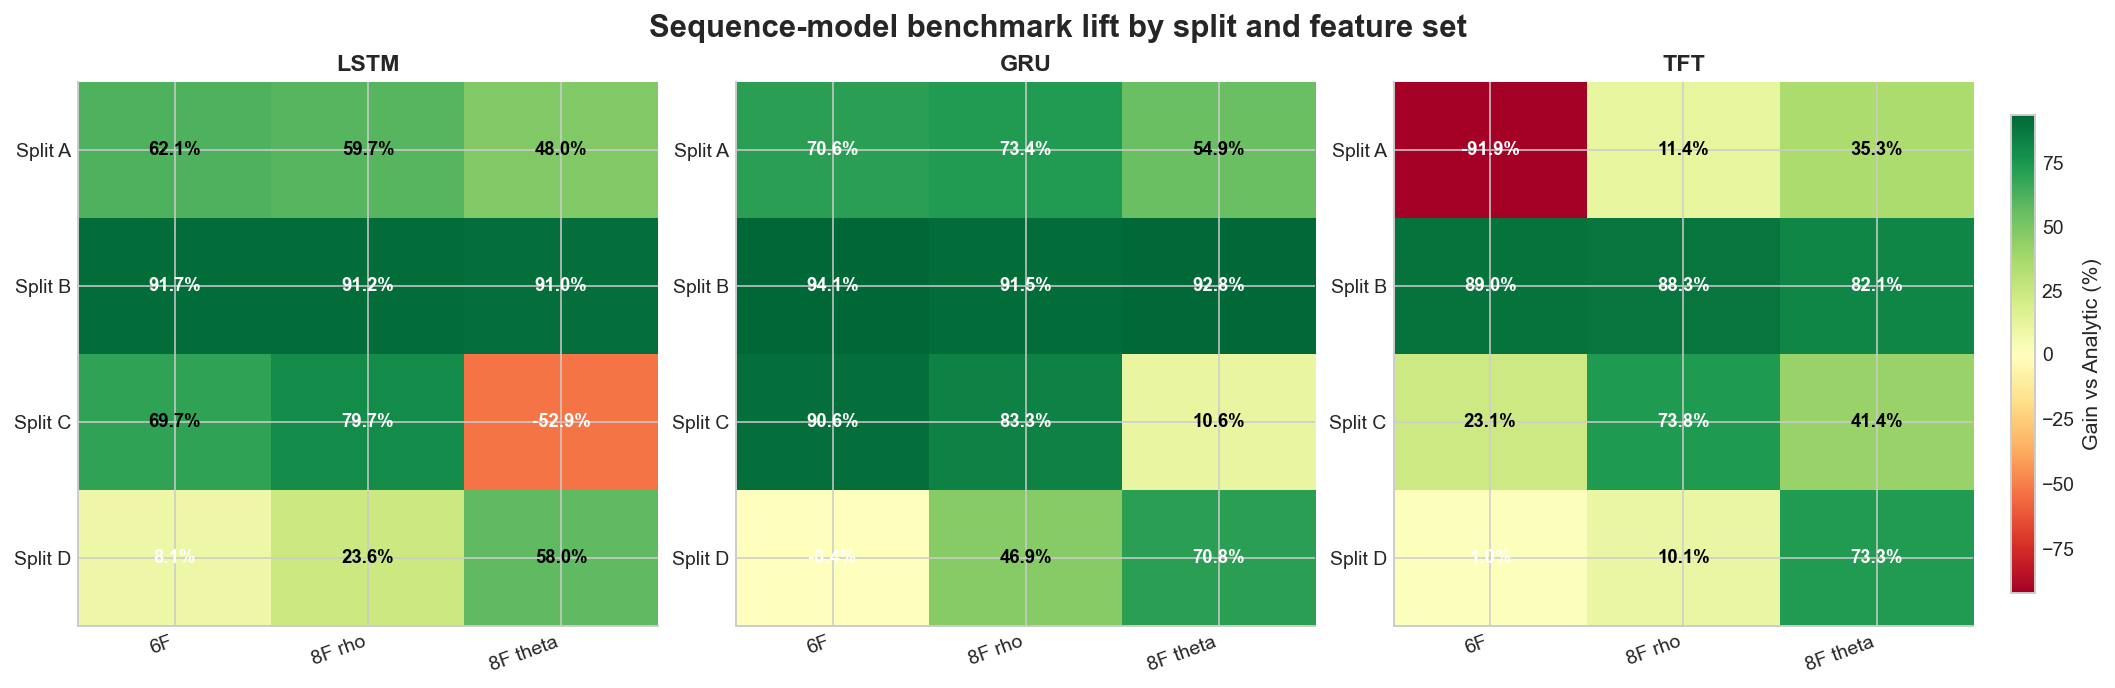

In [9]:
seq_df = df[df['model'].isin(['LSTM', 'GRU', 'TFT'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
norm = colors.TwoSlopeNorm(vmin=seq_df['GainPct'].min(), vcenter=0.0, vmax=seq_df['GainPct'].max())
cmap = plt.cm.RdYlGn

for ax, model in zip(axes, ['LSTM', 'GRU', 'TFT']):
    heat = (
        seq_df[seq_df['model'] == model]
        .pivot(index='split', columns='feature_label', values='GainPct')
        .reindex(index=SPLIT_ORDER)
    )
    im = ax.imshow(heat.values, cmap=cmap, norm=norm, aspect='auto')
    ax.set_title(model)
    ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=20, ha='right')
    ax.set_yticks(range(len(heat.index)), [f'Split {s}' for s in heat.index])

    for row_idx, split in enumerate(heat.index):
        for col_idx, feature in enumerate(heat.columns):
            value = heat.loc[split, feature]
            text_color = 'black' if 10 <= value <= 70 else 'white'
            ax.text(col_idx, row_idx, f'{value:.1f}%', ha='center', va='center', fontsize=9.5, color=text_color, fontweight='bold')

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.88, pad=0.02)
cbar.set_label('Gain vs Analytic (%)')
fig.suptitle('Sequence-model benchmark lift by split and feature set', fontsize=16, fontweight='bold')
plt.show()


## Figure 7. Gain Trajectories Across Splits

This complements the rank plot with the actual economic lift over the analytic benchmark.
It answers whether a model wins by a little or by a lot as the split changes.


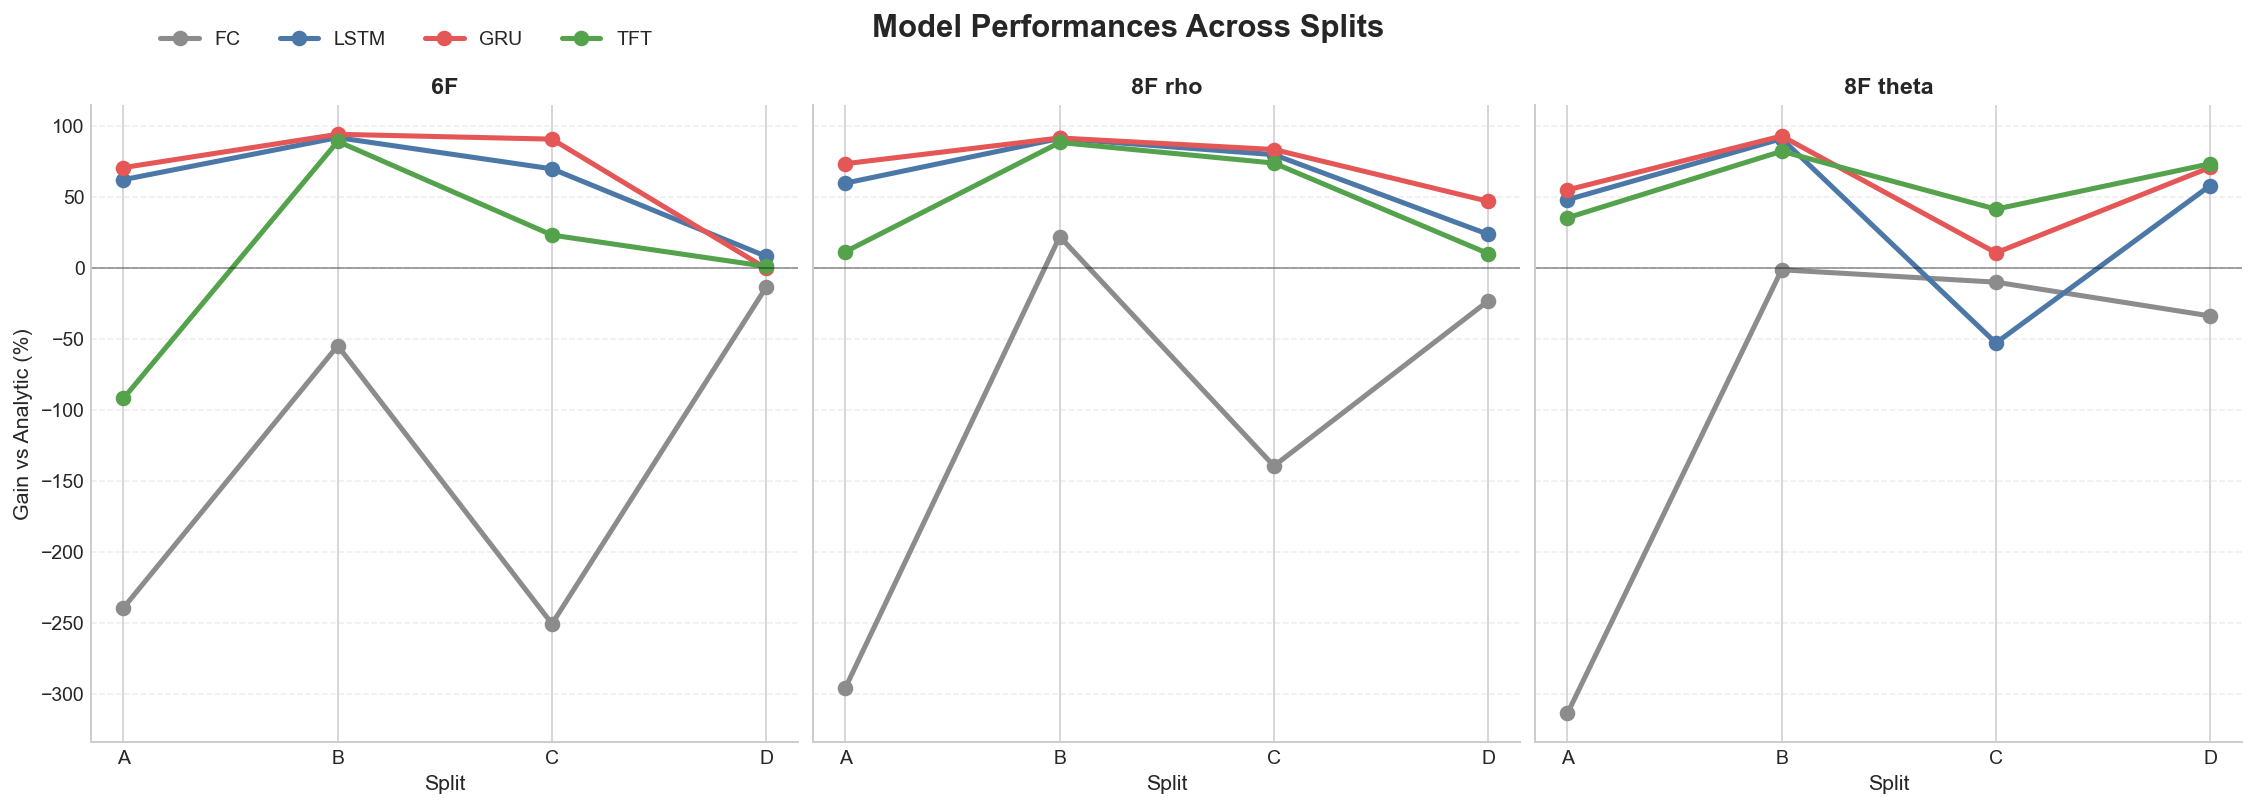

In [10]:
gain_seq = df[df['model'].isin(['FC', 'LSTM', 'GRU', 'TFT'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharey=True, constrained_layout=True)

for ax, feature in zip(axes, FEATURE_ORDER):
    feature_slice = gain_seq[gain_seq['feature'] == feature].copy()
    for model in ['FC', 'LSTM', 'GRU', 'TFT']:
        line = feature_slice[feature_slice['model'] == model].sort_values('split')
        ax.plot(
            line['split'].astype(str),
            line['GainPct'],
            color=MODEL_COLORS[model],
            marker='o',
            linewidth=2.6,
            markersize=7,
            label=model,
        )
    ax.set_title(feature_slice['feature_label'].iloc[0])
    ax.set_xlabel('Split')
    ax.set_xticks(SPLIT_ORDER)
    ax.axhline(0, color='black', linewidth=1, alpha=0.35)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

axes[0].set_ylabel('Gain vs Analytic (%)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=4, loc='upper left', bbox_to_anchor=(0.06, 1.08), frameon=False)
fig.suptitle('Model Performances Across Splits', fontsize=16, fontweight='bold', y=1.08)
# fig.savefig(FIG_OUTPUT / '4.7-Gain Trajectories Across Splits.png', bbox_inches='tight')
plt.show()


## Figure 8. R2 vs Gain Map for Sequence Models

This figure combines statistical fit and benchmark lift in one place.
Points in the upper-right are the most attractive: high explanatory power and large gain over the analytic baseline.


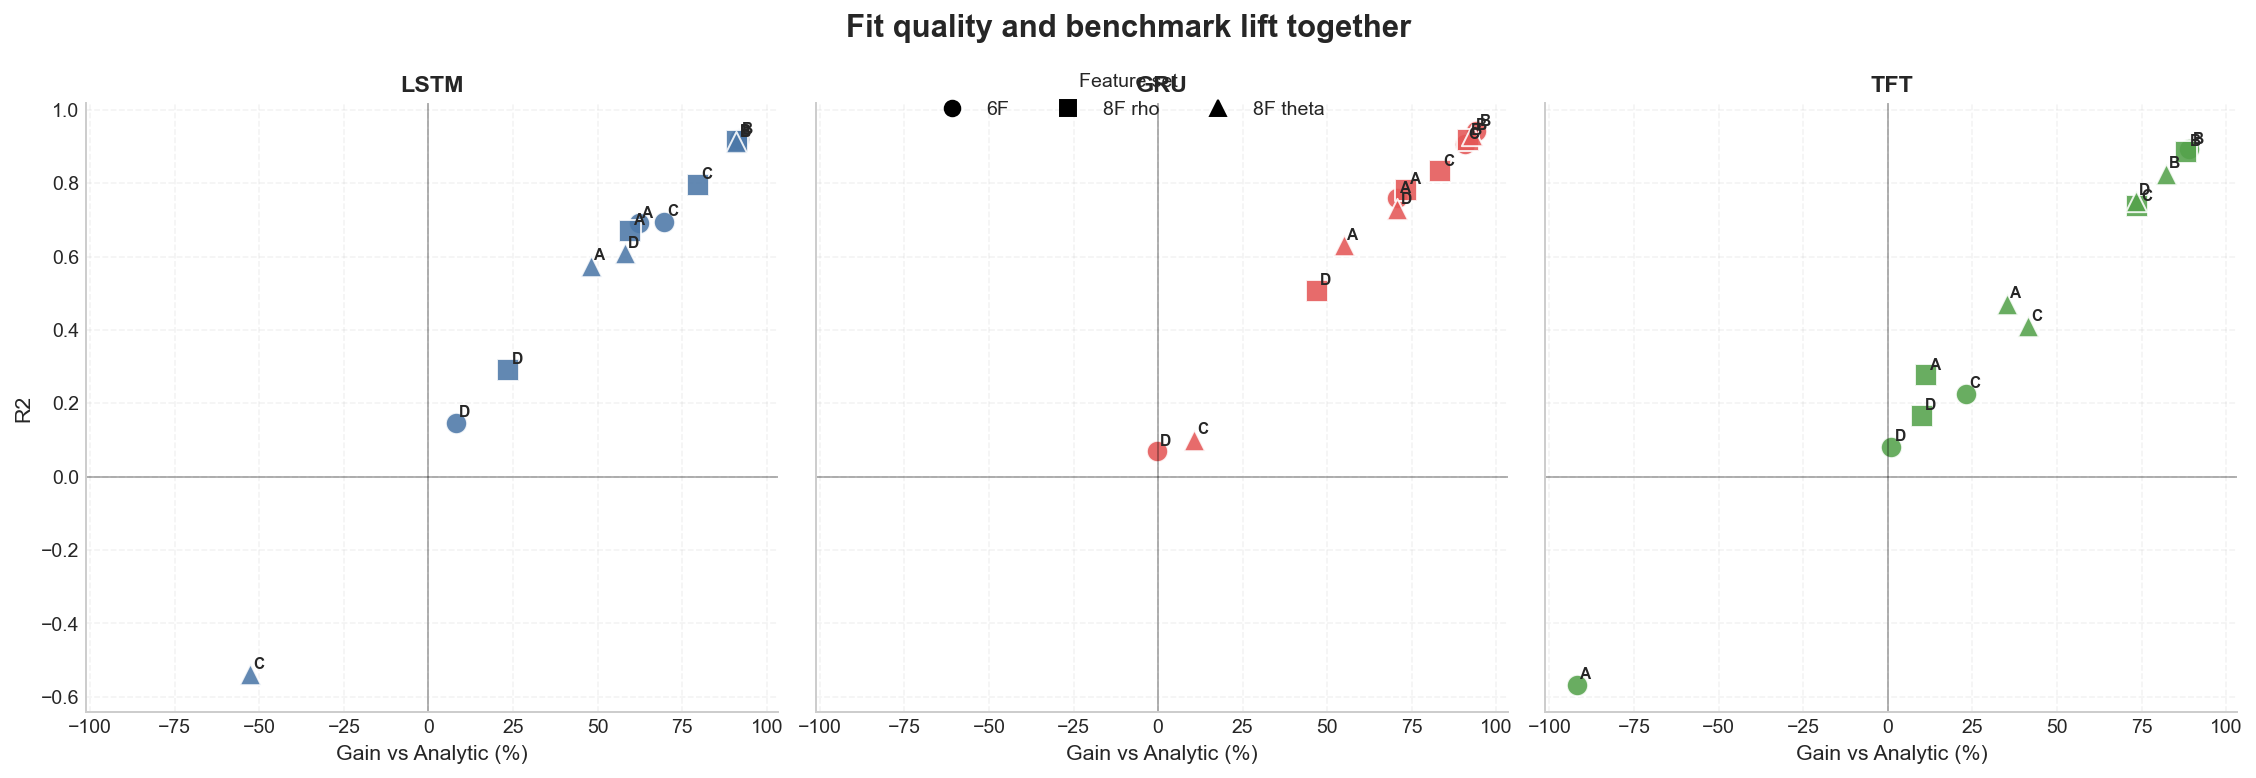

In [11]:
seq_df = df[df['model'].isin(['LSTM', 'GRU', 'TFT'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True, constrained_layout=True)

for ax, model in zip(axes, ['LSTM', 'GRU', 'TFT']):
    sub = seq_df[seq_df['model'] == model].copy()
    for feature in FEATURE_ORDER:
        pts = sub[sub['feature'] == feature]
        ax.scatter(
            pts['GainPct'],
            pts['R2'],
            s=120,
            color=MODEL_COLORS[model],
            marker=FEATURE_MARKERS[feature],
            alpha=0.88,
            edgecolor='white',
            linewidth=1.0,
        )
        for _, row in pts.iterrows():
            ax.text(row['GainPct'] + 1.0, row['R2'] + 0.015, row['split'], fontsize=8, fontweight='bold')

    ax.set_title(model)
    ax.axhline(0, color='black', linewidth=1, alpha=0.3)
    ax.axvline(0, color='black', linewidth=1, alpha=0.3)
    ax.grid(True, linestyle='--', alpha=0.25)
    ax.set_xlabel('Gain vs Analytic (%)')

axes[0].set_ylabel('R2')
feature_handles = [
    Line2D([0], [0], marker=FEATURE_MARKERS[f], color='black', linestyle='None', markersize=8, label=df.loc[df['feature'] == f, 'feature_short'].iloc[0])
    for f in FEATURE_ORDER
]
fig.legend(handles=feature_handles, title='Feature set', ncols=3, loc='upper center', bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle('Fit quality and benchmark lift together', fontsize=16, fontweight='bold', y=1.08)
plt.show()


## Figure 9. Benchmark-Lift Leaderboard for Sequence Models

This is a presentation-focused summary of `Gain vs Analytic` for `LSTM`, `GRU`, and `TFT`.
Each row is one split-feature bucket, the gray bar shows the full gain range across models, and the outlined point marks the winner.


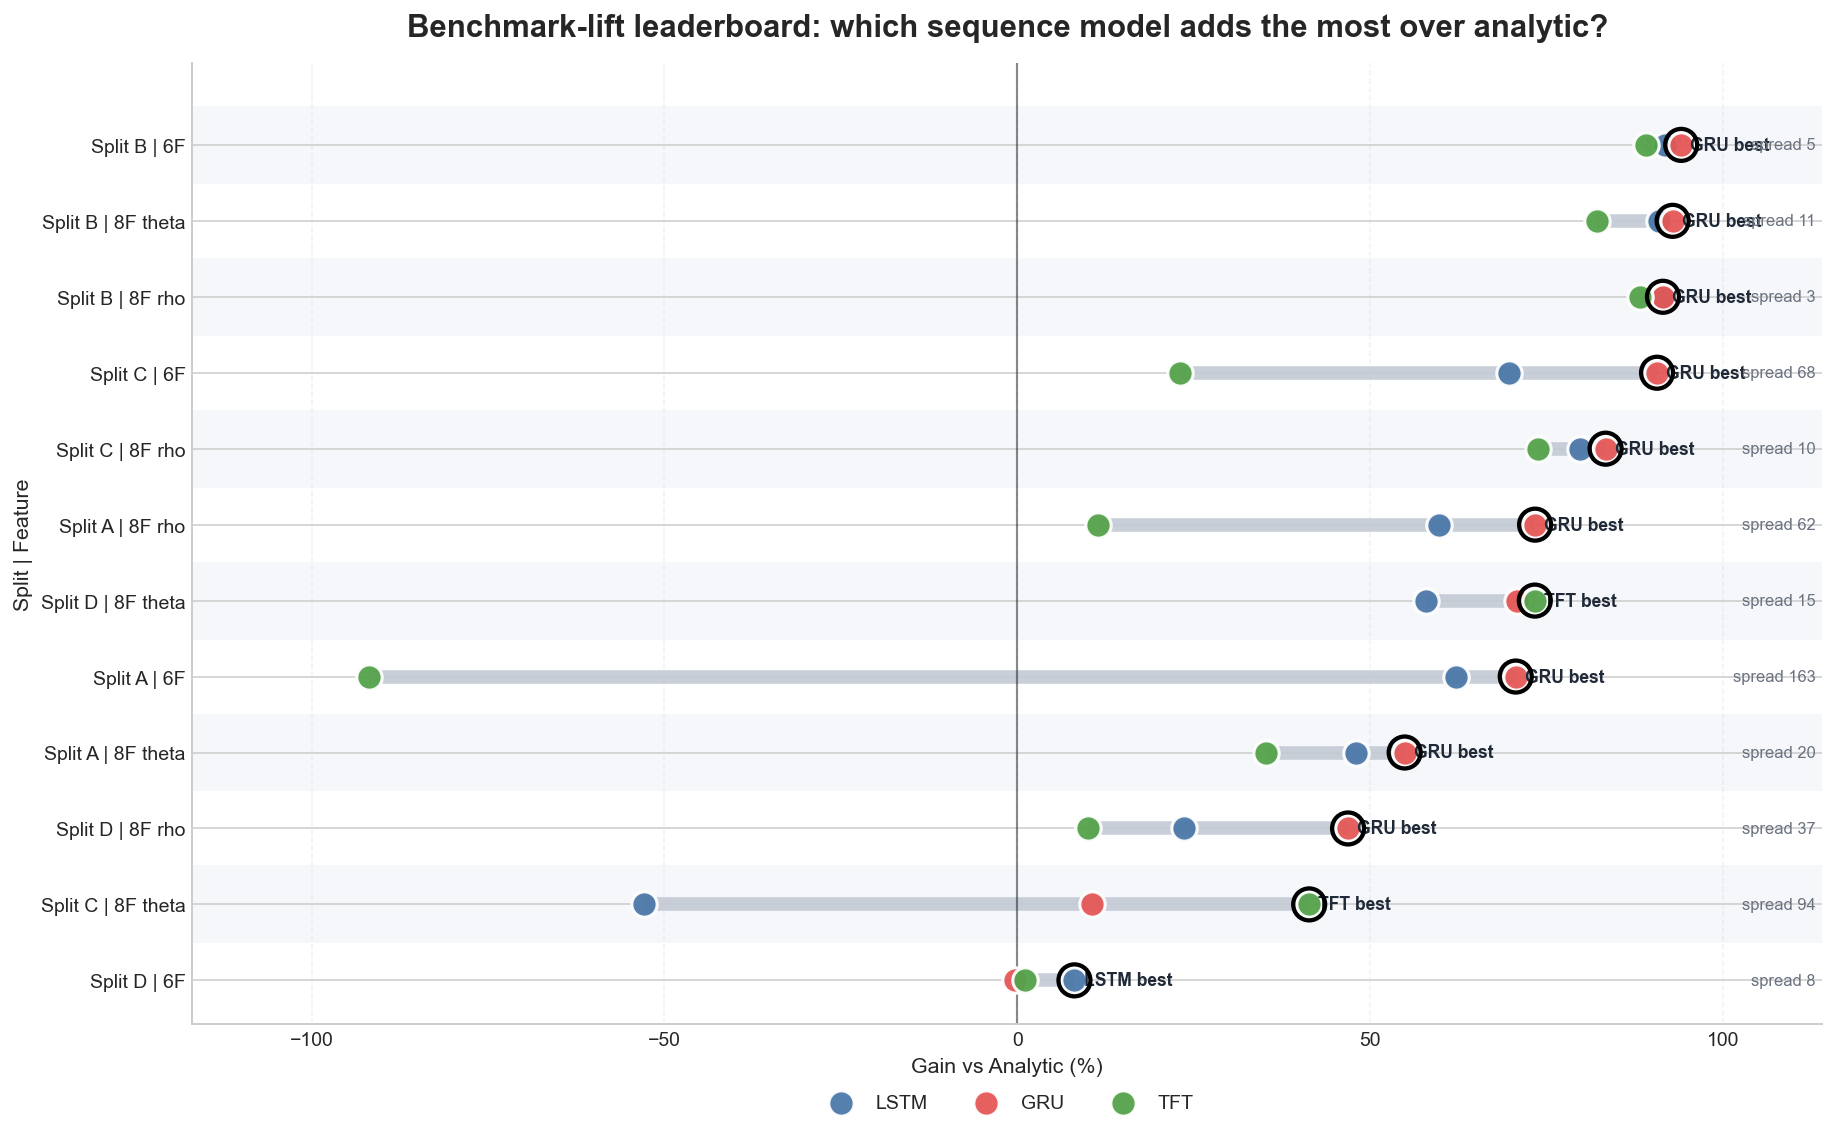

In [12]:
seq_gain = df[df['model'].isin(['LSTM', 'GRU', 'TFT'])].copy()
seq_gain['bucket'] = seq_gain.apply(lambda r: f"Split {r['split']} | {r['feature_label']}", axis=1)

bucket_order = (
    seq_gain.groupby('bucket')['GainPct']
    .max()
    .sort_values(ascending=False)
    .index
    .tolist()
)
ypos = {bucket: idx for idx, bucket in enumerate(bucket_order)}

spread = (
    seq_gain.groupby('bucket')['GainPct']
    .agg(['min', 'max', 'mean'])
    .reindex(bucket_order)
)
spread['range'] = spread['max'] - spread['min']

winner_df = (
    seq_gain.loc[seq_gain.groupby('bucket')['GainPct'].idxmax()]
    .set_index('bucket')
    .reindex(bucket_order)
)

fig, ax = plt.subplots(figsize=(13, 8), constrained_layout=True)

for idx, bucket in enumerate(bucket_order):
    if idx % 2 == 0:
        ax.axhspan(idx - 0.5, idx + 0.5, color='#f5f7fb', zorder=0)

for bucket, row in spread.iterrows():
    y = ypos[bucket]
    ax.hlines(y, row['min'], row['max'], color='#c4cad4', linewidth=7, alpha=0.9, zorder=1)

for model in ['LSTM', 'GRU', 'TFT']:
    sub = seq_gain[seq_gain['model'] == model].copy()
    ys = sub['bucket'].map(ypos)
    ax.scatter(
        sub['GainPct'],
        ys,
        s=170,
        color=MODEL_COLORS[model],
        edgecolor='white',
        linewidth=1.6,
        alpha=0.95,
        label=model,
        zorder=3,
    )

for bucket, row in winner_df.iterrows():
    y = ypos[bucket]
    ax.scatter(row['GainPct'], y, s=270, facecolors='none', edgecolors='black', linewidth=2.2, zorder=4)
    ax.text(row['GainPct'] + 1.3, y, f"{row['model']} best", va='center', fontsize=9, fontweight='bold', color='#1f2937')

xmin = seq_gain['GainPct'].min() - 25
xmax = seq_gain['GainPct'].max() + 20
ax.set_xlim(xmin, xmax)

for bucket, row in spread.iterrows():
    y = ypos[bucket]
    ax.text(xmax - 1.0, y, f"spread {row['range']:.0f}", ha='right', va='center', fontsize=8.5, color='#6b7280')

ax.set_yticks(range(len(bucket_order)), bucket_order)
ax.invert_yaxis()
ax.set_xlabel('Gain vs Analytic (%)')
ax.set_ylabel('Split | Feature')
ax.axvline(0, color='black', linewidth=1.1, alpha=0.45)
ax.grid(axis='x', linestyle='--', alpha=0.25)
ax.legend(ncols=3, loc='lower center', bbox_to_anchor=(0.5, -0.11), frameon=False)
ax.set_title('Benchmark-lift leaderboard: which sequence model adds the most over analytic?', fontsize=16, fontweight='bold', pad=14)
plt.show()


## Presentation Takeaways

Use these as candidate slide captions after you inspect the charts:

- `GRU` is the most consistent winner overall, especially on splits A, B, and C.
- `TFT` becomes the strongest choice in split D when paired with `8F theta`.
- `FC` is fast, but the accuracy sacrifice is large enough that it rarely belongs on the frontier.
- Split D is the hardest regime: model rankings compress, and the best feature choice changes more noticeably there.


## Figure 10. Rank and Gain Trajectories in One View

This combines `4.3` and `4.7` into one slide-friendly chart.
Each column is one feature set, with `R2` rank trajectories on the top row and `Gain vs Analytic` trajectories on the bottom row.


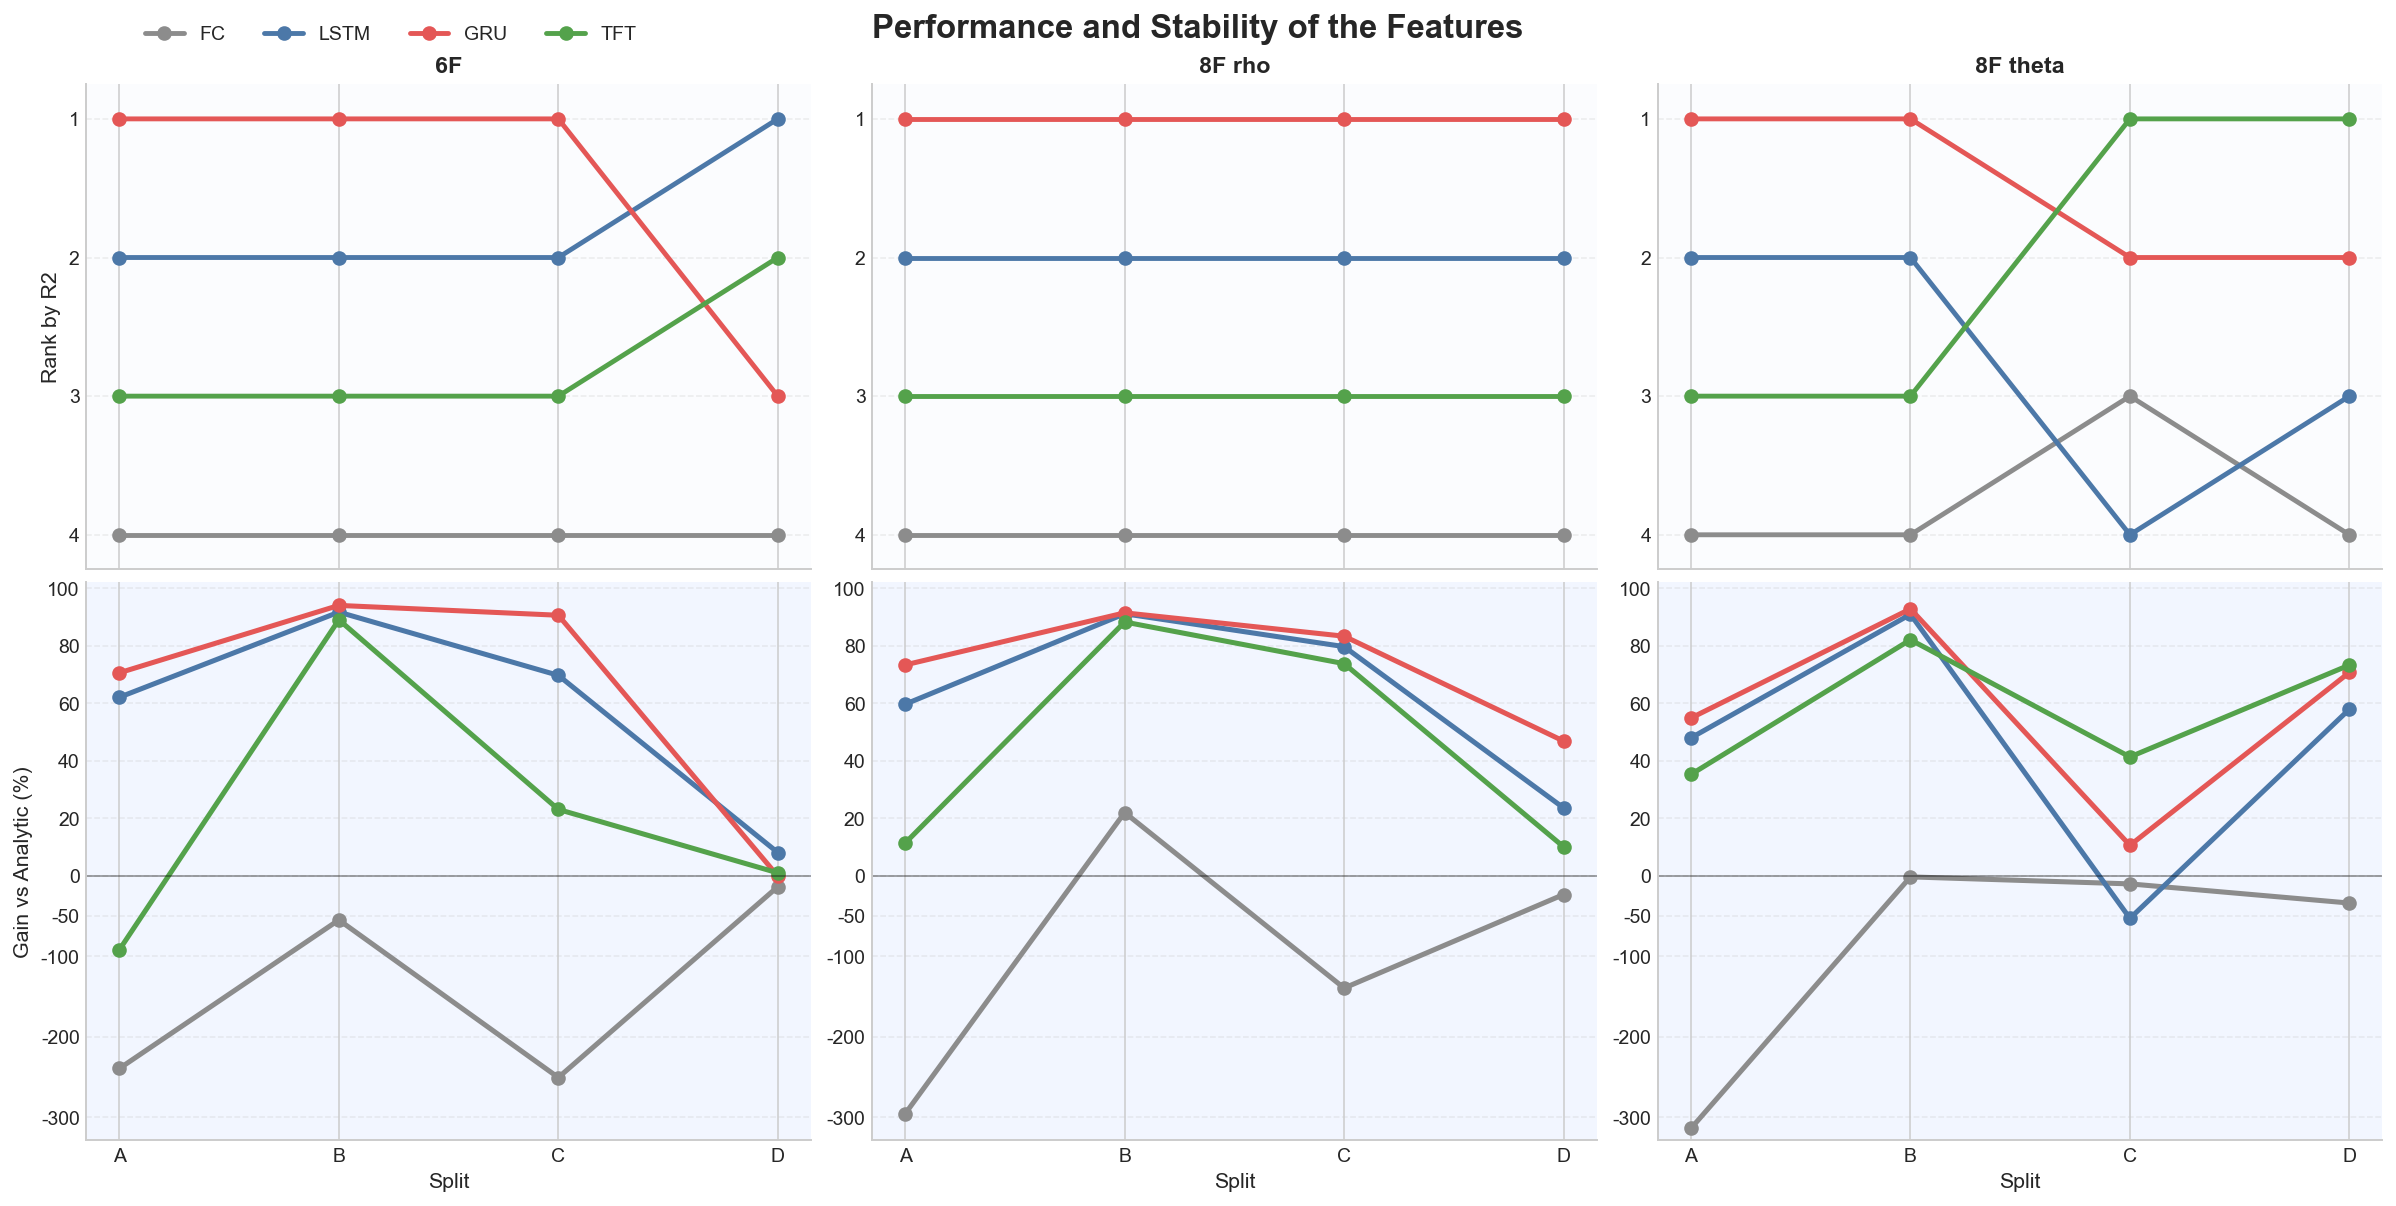

In [33]:
combined_models = ['FC', 'LSTM', 'GRU', 'TFT']
combined_df = df[df['model'].isin(combined_models)].copy()

rank_combined = combined_df.copy()
rank_combined['rank'] = rank_combined.groupby(['split', 'feature'], observed=True)['R2'].rank(ascending=False, method='first')

gain_combined = combined_df.copy()

def compress_negative_gain(values, negative_scale=0.28):
    values = np.asarray(values, dtype=float)
    return np.where(values >= 0, values, values * negative_scale)

gain_tick_values = np.array([-300, -200, -100, -50, 0, 20, 40, 60, 80, 100])
gain_tick_positions = compress_negative_gain(gain_tick_values)
gain_ymin = compress_negative_gain(np.array([gain_combined['GainPct'].min() - 15]))[0]
gain_ymax = gain_combined['GainPct'].max() + 8

fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 8.5),
    sharex='col',
    constrained_layout=True,
    gridspec_kw={'height_ratios': [1.0, 1.15]}
)

for col, feature in enumerate(FEATURE_ORDER):
    top_ax = axes[0, col]
    bottom_ax = axes[1, col]

    rank_slice = rank_combined[rank_combined['feature'] == feature].copy()
    gain_slice = gain_combined[gain_combined['feature'] == feature].copy()

    for model in combined_models:
        rank_line = rank_slice[rank_slice['model'] == model].sort_values('split')
        gain_line = gain_slice[gain_slice['model'] == model].sort_values('split')

        top_ax.plot(
            rank_line['split'].astype(str),
            rank_line['rank'],
            color=MODEL_COLORS[model],
            marker='o',
            linewidth=2.5,
            markersize=6.5,
            label=model if col == 0 else None,
        )
        bottom_ax.plot(
            gain_line['split'].astype(str),
            compress_negative_gain(gain_line['GainPct']),
            color=MODEL_COLORS[model],
            marker='o',
            linewidth=2.6,
            markersize=6.5,
            label=model if col == 0 else None,
        )

    feature_name = rank_slice['feature_label'].iloc[0]
    top_ax.set_title(feature_name, fontsize=12, fontweight='bold')
    top_ax.set_ylim(4.25, 0.75)
    top_ax.set_yticks([1, 2, 3, 4])
    top_ax.grid(axis='y', linestyle='--', alpha=0.35)
    top_ax.set_facecolor('#fbfcfe')

    bottom_ax.axhline(0, color='black', linewidth=1, alpha=0.35)
    bottom_ax.set_ylim(gain_ymin, gain_ymax)
    bottom_ax.set_yticks(gain_tick_positions, [str(v) for v in gain_tick_values])
    bottom_ax.grid(axis='y', linestyle='--', alpha=0.35)
    bottom_ax.set_xlabel('Split')
    bottom_ax.set_xticks(SPLIT_ORDER)
    bottom_ax.set_facecolor('#f2f6ff')

axes[0, 0].set_ylabel('Rank by R2')
axes[1, 0].set_ylabel('Gain vs Analytic (%)')




handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=4, loc='upper left', bbox_to_anchor=(0.05, 1.0), frameon=False)
fig.suptitle('Performance and Stability of the Features', fontsize=17, fontweight='bold')
fig.savefig(FIG_OUTPUT / '4.3-7-Model Performance and Stability.png', bbox_inches='tight')
plt.show()
